In [10]:
import matplotlib.pyplot as plt
import numpy as np

### Introduzione della misura della distribuzione di velocità 

In [11]:
def boltzmann(v, T):
    return np.power(2*np.pi*T, -3/2)*4*np.pi*np.power(v,2)*np.exp(-np.power(v,2)/(2*T))

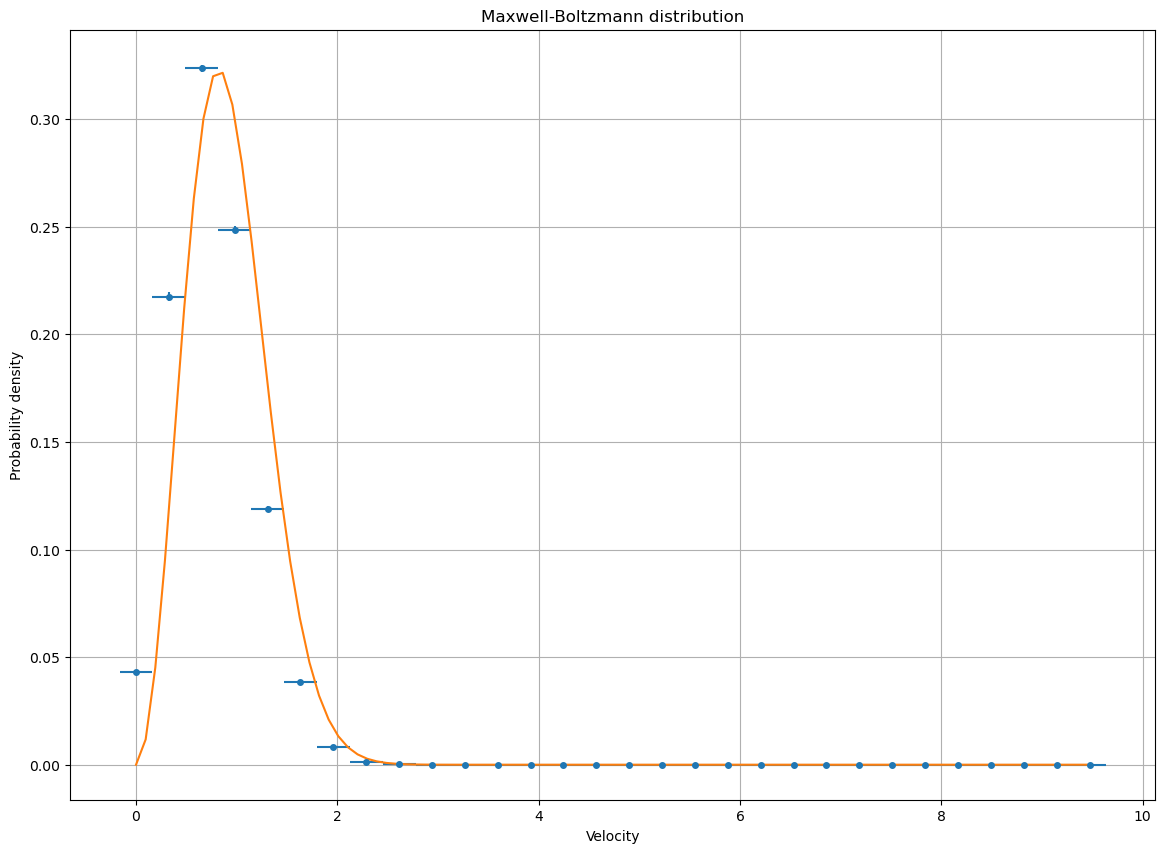

In [12]:
x, func, error = np.loadtxt("../OUTPUT/pofv.dat", usecols=(0,1,2), skiprows=1, unpack='true')
v_temp = np.loadtxt('../OUTPUT/temperature.dat', usecols= 2)

temp = v_temp[-1]
x_teo = np.linspace(0.0, x[-1], 100)
dv = (x[1]-x[0])*0.5

plt.figure(figsize=(14,10))

fit_func_raw = boltzmann(x_teo, temp)
# Calcolo l'area della curva sperimentale per scalare del fattore giusto la curva analitica
area_dati = np.trapezoid(func, x)
fit_func = fit_func_raw * (area_dati)

plt.errorbar(x,func,yerr=error,xerr=dv,fmt='o',markersize=4)
plt.plot(x_teo,fit_func)
plt.xlabel('Velocity')
plt.ylabel('Probability density')
plt.title("Maxwell-Boltzmann distribution")
plt.grid(True)
plt.show()


### Commenti
Questa simulazione è stata compiuta ponendo $T^* = 2.0, \rho = 0.8, r_c = 2.5$ e con $N_{blocks} = 20$ ciascuno da $N_{steps} = 1000$. Il grafico della distribuzione di velocità $p(v^*, T^*)$ segue quello della legge di Maxwell-Boltzmann dandoci conferma che le misure sulla velocità sono state eseguite correttamente. Le piccole discrepanze che si osservano possono essere ricondotte al fatto che il sistema iniziale non era all'equilibrio, per cui si potrebbe rifare un'altra simulazione utilizzando un sistema che è stato precedente evoluto fino alla situazione di equilibrio.